In [2]:
setwd('/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/')
devtools::load_all('utils/modules/R/prstools')

i Loading PRStools

Loading required package: bigsnpr

Loading required package: bigstatsr

Loading required package: data.table

Loading required package: bigassertr

! Adding files missing in collate: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/prstools/R/qc_binary_sumstat.R



In [2]:
args <- list(
    path_bed_pred = "data/prs/hapmap/ukb_hapmap_500k_eur_chr21.bed",
    #path_ld_bed = "data/prs/hapmap/ld/unrel_eur_10k/short_ukb_hapmap_rand_10k_eur.bed",
    path_ld_bed = "data/prs/hapmap/ld/unrel_eur_10k/short_merged_ukb_hapmap_rand_10k_eur.bed",
    #path_ld_matrix = "data/prs/hapmap/ld/corr/ukb_eu_10k_ld_CAD_combined.rda",
    gwas = "data/prs/sumstat/ukb_hapmap_500k_eur_CAD_combined.txt.gz",
    #path_sumstat = "data/prs/hapmap/ld/corr/ukb_eu_10k_ld_CAD_combined_betas.txt.gz",
    chrom = '21'
)

In [5]:
#NCORES <- nb_cores()
#tmp <- tempfile(tmpdir = "data/tmp/tmp-data")
#on.exit(file.remove(paste0(tmp, ".sbk")), add = TRUE)

In [6]:

snp <- readRDS(args$path_ld_matrix)
df_beta <- fread(args$path_sumstat)
#ld_data <- load_bigsnp_from_bed(args$path_ld_bed)
#sumstats <- read_hail_sumstat(args$path_sumstat)

In [5]:
corr <- snp$corr

In [7]:
rds <- "data/prs/hapmap/ld/corr/"

ERROR: Error in corr[1:100, 1:100]: object of type 'S4' is not subsettable


# Test PRS

In [2]:
library(ggplot2)

In [3]:
files <- list.files('data/prs/scores/test/', pattern = '.txt.gz', full.names = TRUE)
print(length(files))
d <- do.call(rbind, lapply(1:22, function(x) {
    f <- files[grepl(paste0("chr",x,".txt.gz"),files)]
    print(f)
    if (length(f)){
        d <- fread(f)
        d$chr <- paste0("chr",x)
        return(d)
    }
  
}))

[1] 24
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr1.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr2.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr3.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr4.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr5.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr6.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr7.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr8.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr9.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr10.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr11.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr12.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr13.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr14.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr15.txt.gz"
[1] "data/prs/scores/test//prs_inf_CAD_combined_chr16.txt.gz"
[1] "data/

ERROR: Error in fread("data/phenotypes/curated_phenotypes.tsv"): could not find function "fread"


In [6]:
pgs <- fread('data/prs/scores/ukb_eur_500k_hm3_binary_pgs.txt.gz')
#pgs <- fread('data/prs/scores/test/test_ukb_by_chrom_500k_pgs.txt.gz')
pgs_phenotypes <- colnames(pgs)[-1]
phenotypes <- fread('data/phenotypes/curated_phenotypes.tsv')

In [53]:
d <- do.call(rbind,lapply(pgs_phenotypes, function(p){
    df_pheno <- phenotypes[,c('eid',p), with = FALSE]
    colnames(df_pheno) <- c('sid','phenotype')
    df_pgs <- pgs[,c('sid',p), with = FALSE]
    mrg <- merge(df_pgs, df_pheno, all.x = TRUE)
    colnames(mrg) <- c('sid','pgs','is_case')
    #mrg$is_case[is.na(mrg$is_case)] <- 0
    mrg$phenotype <- p
    mrg$total_cases <- sum(mrg$is_case)
    return(mrg)
}))

In [54]:
#pct <- 0.01
#lower_bound <- quantile(d$pgs, pct)
#upper_bound <- quantile(d$pgs, 1 - pct)
#d$category <- ifelse(d$pgs >= upper_bound, paste0('Top ',pct*100,'% risk'),
#                    ifelse(d$pgs <= lower_bound, paste0('Bottom ',pct*100,'% risk'), NA))

#samples_upper <- M$sid[M_pheno$pgs >= upper_bound]
#samples_lower <- M$sid[M$pgs <= lower_bound]

In [147]:
#write(paste('* TRUE/FALSE indicate',phenotype, 'status'),stdout())

#tbl <- table(d$is_case, d$category)
#tbl

* TRUE/FALSE indicate CAD_combined status


       
        Bottom 1% risk Top 1% risk
  FALSE           3806         987
  TRUE               7        2826

In [ ]:
OR 

In [192]:
dt <- d
M <- do.call(rbind, lapply(seq(0.005,0.20, by = 0.005), function(pct){

    lower_bound <- quantile(dt$pgs, pct)
    upper_bound <- quantile(dt$pgs, 1 - pct)
    dt$category <- ifelse(dt$pgs >= upper_bound, 'top',
                    ifelse(dt$pgs <= lower_bound, 'bottom', NA))

    bottom_false <- sum(dt$category == 'bottom' & !dt$is_case, na.rm = TRUE)
    bottom_true <- sum(dt$category == 'bottom' & dt$is_case, na.rm = TRUE) 
    top_false <- sum(dt$category == 'top' & !dt$is_case, na.rm = TRUE) 
    top_true <- sum(dt$category == 'top' & dt$is_case, na.rm = TRUE)
    
    lh <- (bottom_false / bottom_true) / (top_false / top_true)
    logor <- log((bottom_false*top_true) / (bottom_true*top_false))
    se_log_or <- sqrt((1/bottom_true) + (1/bottom_false) + (1/top_false) + (1/top_true))
    ci <- qnorm(0.975)*se_log_or
    
    return(data.frame(
        pct = pct,
        bottom_false = bottom_false, 
        bottom_true = bottom_true,
        top_false = top_false,
        top_true = top_true,
        bottom_case_frac = bottom_true / (bottom_false + bottom_true),
        top_case_frac = top_true / (top_true + top_false),
        lh = lh,
        logor = logor,
        logor_ci_upper = logor + ci,
        logor_ci_lower = logor - ci
        
        
    ))
}))

In [193]:
tail(M)

,pct,bottom_false,bottom_true,top_false,top_true,bottom_case_frac,top_case_frac,lh,logor,logor_ci_upper,logor_ci_lower
,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
35,0.175,66227,484,47058,19647,0.007255175,0.2945356,57.12846,4.045302,4.136253,3.954352
36,0.180,68102,515,48711,19900,0.007505429,0.2900410,54.02300,3.989410,4.077656,3.901163
37,0.185,69985,538,50363,20154,0.007628717,0.2858034,52.05619,3.952324,4.038707,3.865941
38,0.190,71869,561,52033,20390,0.007745409,0.2815404,50.20155,3.916046,4.000682,3.831410
39,0.195,73742,594,53724,20605,0.007990745,0.2772135,47.61379,3.863122,3.945446,3.780799
40,0.200,75617,625,55378,20857,0.008197581,0.2735882,45.56737,3.819192,3.899508,3.738876


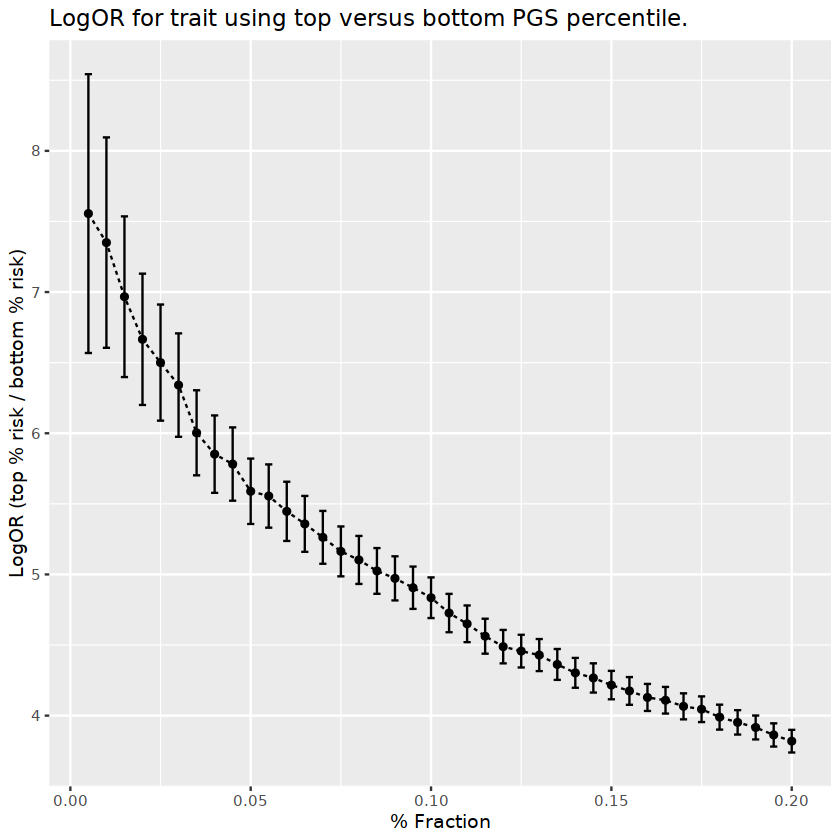

In [194]:
ggplot(M, aes(x=pct, y = logor, ymax = logor_ci_upper, ymin = logor_ci_lower)) +
    geom_point() +
    geom_errorbar(width = 2e-3) +
    geom_line(linetype = 'dashed') +
    xlab('% Fraction') + 
    ylab('LogOR (top % risk / bottom % risk)') +
    ggtitle('LogOR for trait using top versus bottom PGS percentile.')

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   [37] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   [73] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [109] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [145] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [181] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [217] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [253] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [289] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [325] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [361] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [397] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [433] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [469] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [505] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [541] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [577] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [613] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [649] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [685] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [721] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [757] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [793] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [829] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [865] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [901] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [937] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [973] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1009] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1045] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1081] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1117] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1153] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1189] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1225] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1261] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1297] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1333] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1369] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1405] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1441] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1477] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1513] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1549] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1585] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1621] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1657] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1693] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1729] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1765] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [18

In [46]:
pgs_phenotypes

[1] "ADHD_combined"     "AD_combined"       "AUT_combined"     
 [4] "CC_combined"       "CD_combined"       "CIRR_combined"    
 [7] "DEP_combined"      "HAM_combined"      "HEM_combined"     
[10] "IBD_combined"      "INF_combined"      "LC_combined"      
[13] "NAFLD_combined"    "NASH_combined"     "PKD_combined"     
[16] "PRO_combined"      "PSOR_combined"     "RF_acute_combined"
[19] "RF_combined"       "STR_combined"      "STR_hem_combined"

In [79]:
lst <- lapply(pgs_phenotypes, function(name){
    d_subset <- d[d$phenotype %in% name,]
    cases <- sum(d_subset$is_case, na.rm = TRUE)
    control <- sum(!d_subset$is_case, na.rm = TRUE)
    undefined <- sum(is.na(d_subset$is_case))
    case_control_ratio <- cases / control
    pct_cases <- round((cases / (control + cases))*100,3)
    print(paste(name, cases))
    #return(paste0(name, ' (',pct_cases,'%)'))
    
})
names(lst) <- pgs_phenotypes

[1] "ADHD_combined 8"
[1] "AD_combined 475"
[1] "AUT_combined 56"
[1] "CC_combined 4974"
[1] "CD_combined 1880"
[1] "CIRR_combined 1256"
[1] "DEP_combined 11392"
[1] "HAM_combined 4692"
[1] "HEM_combined 14798"
[1] "IBD_combined 3383"
[1] "INF_combined 1872"
[1] "LC_combined 2431"
[1] "NAFLD_combined 1541"
[1] "NASH_combined 167"
[1] "PKD_combined 355"
[1] "PRO_combined 302"
[1] "PSOR_combined 5749"
[1] "RF_acute_combined 4221"
[1] "RF_combined 8655"
[1] "STR_combined 9651"
[1] "STR_hem_combined 1723"


In [76]:
pgs_labeller <- function(variable,value){
  return(lst[value])
}

Warning message:
"The labeller API has been updated. Labellers taking `variable` and `value` arguments are now deprecated. See labellers documentation."


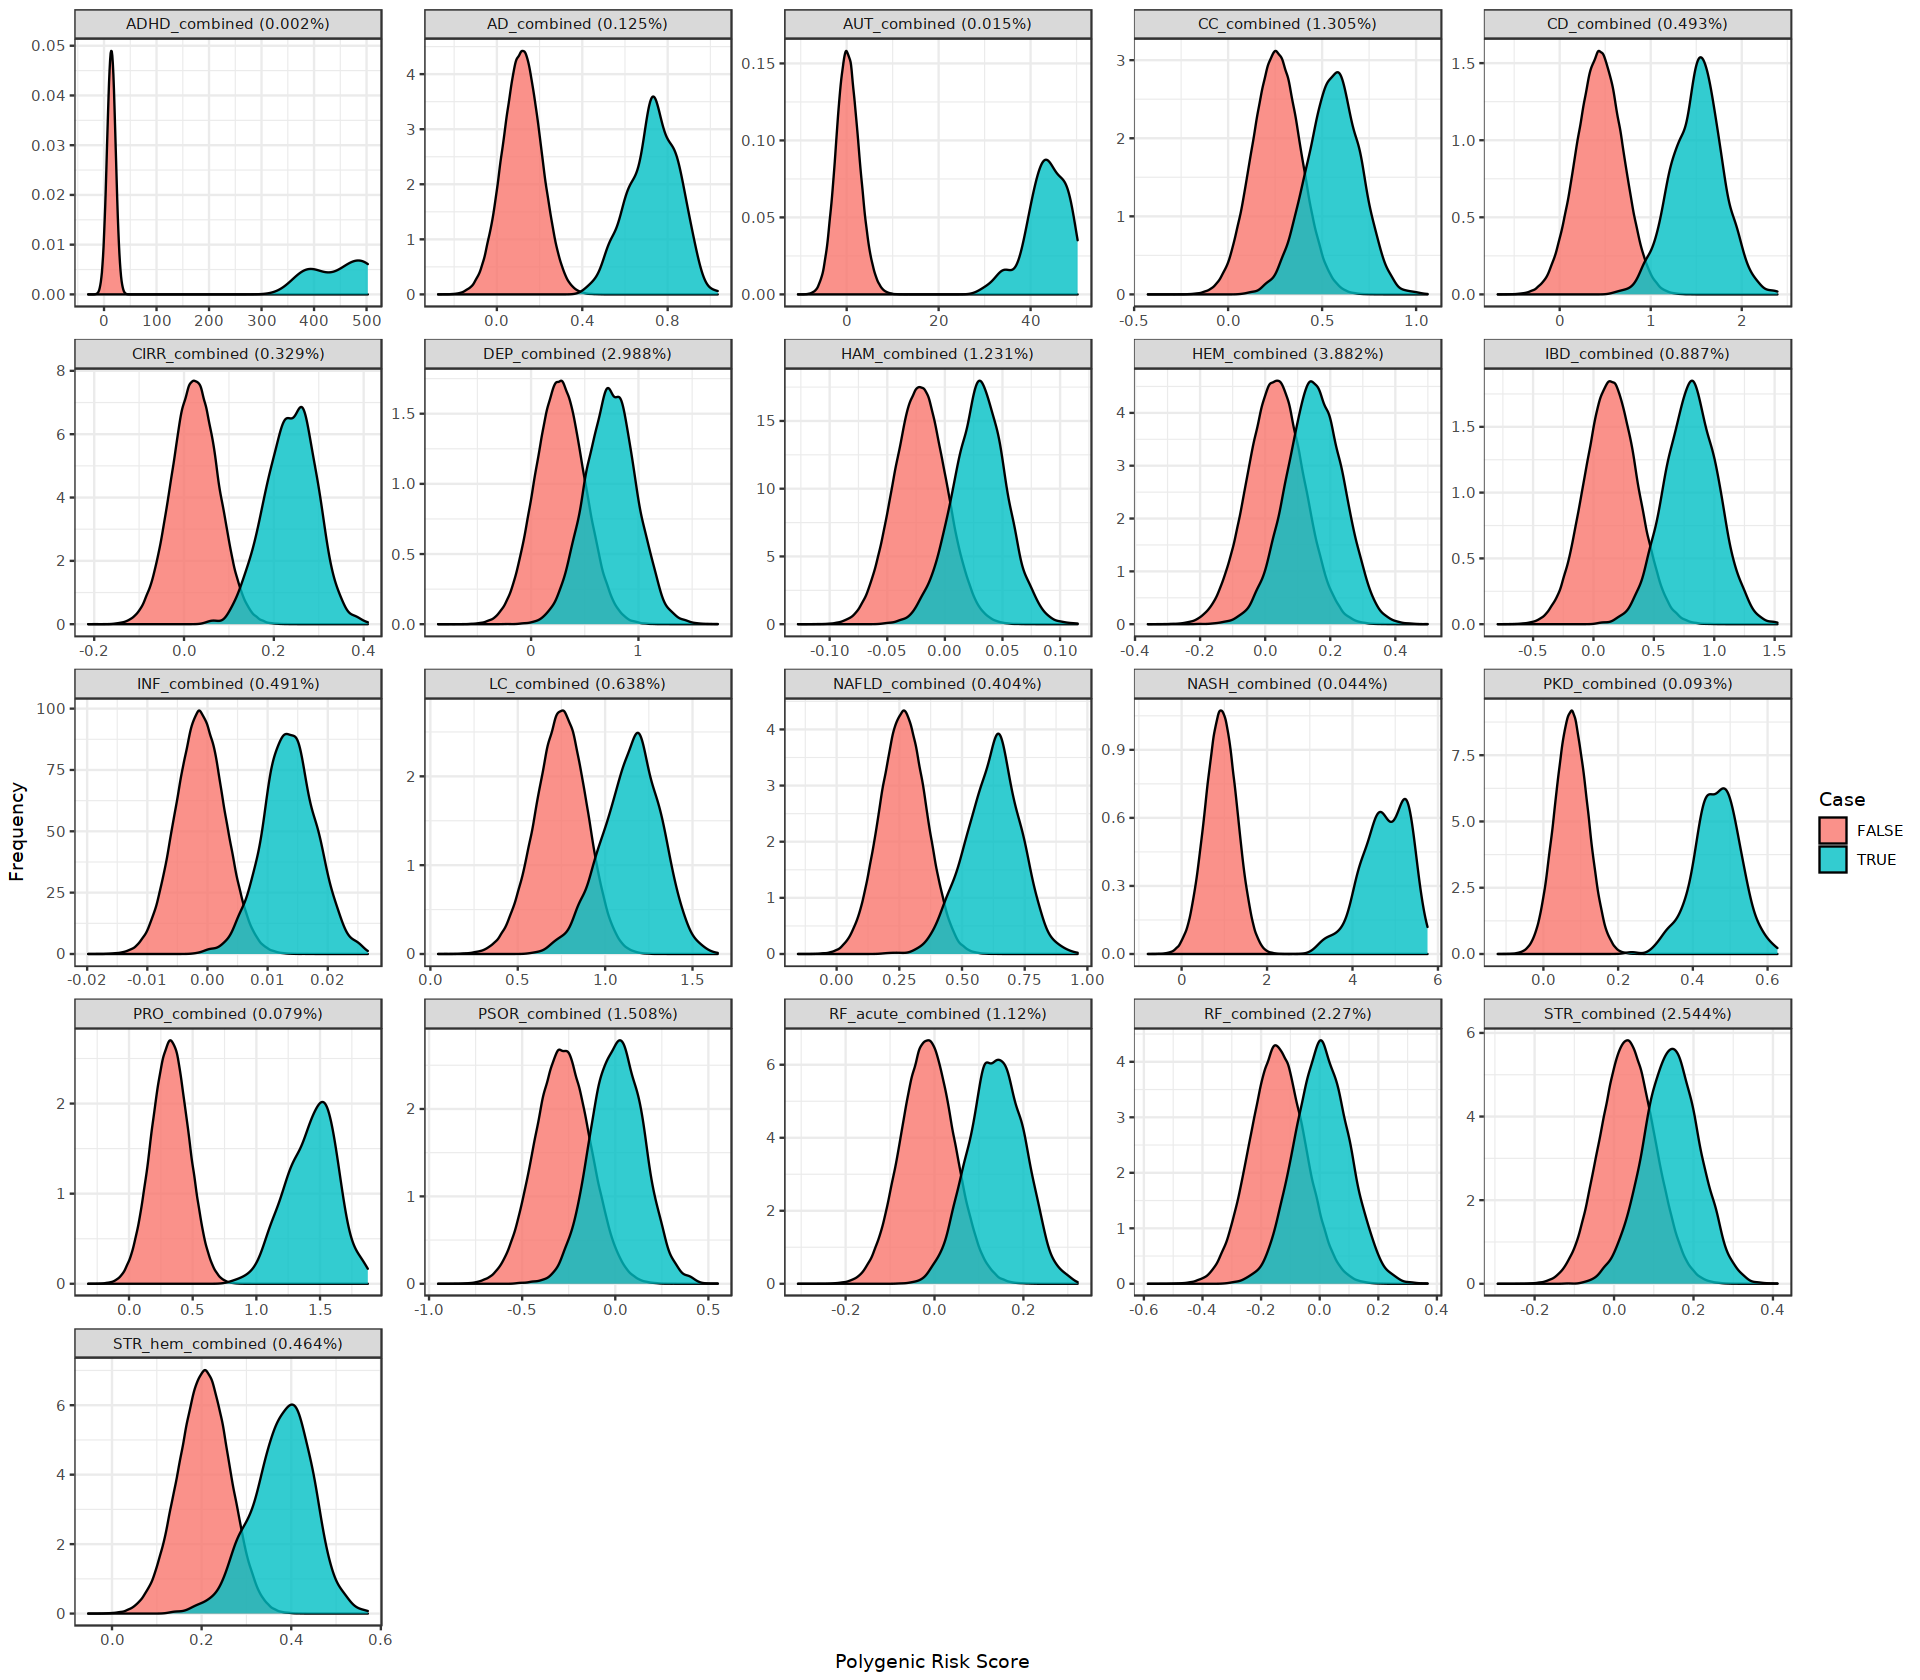

In [78]:
library(ggplot2)
options(repr.plot.width=16, repr.plot.height=14)
#lapply(pgs_phenotypes[5], function(p){
d_subset <- d[!is.na(d$is_case),] #d[d$phenotype %in% p,]
#pheno_true_line <- median(d_subset$pgs[d_subset$is_case], na.rm = TRUE)
#pheno_false_line <- median(d_subset$pgs[!d_subset$is_case], na.rm = TRUE)
p <- ggplot(d_subset, aes(x=pgs, fill=is_case)) +
        geom_density(alpha = 0.8) +
        #geom_vline(xintercept=pheno_true_line, linetype = 'dashed') +
        #geom_vline(xintercept=pheno_false_line, linetype = 'dashed') +
        labs(fill="Case") + 
        xlab('Polygenic Risk Score') +
        ylab("Frequency") +
        theme_bw() +
        facet_wrap(~phenotype, scales = 'free', labeller = pgs_labeller)
p


In [60]:
args <- list(
    path_phenos = "data/phenotypes/curated_phenotypes_binary_header.tsv",
    in_dir = "data/prs/scores",
    pred =  "data/prs/hapmap/ukb_500k/ukb_hapmap_500k_eur_chr21.bed"
)

In [61]:
phenos <- unlist(strsplit(readLines(args$path_phenos), split = "\\s+", perl = TRUE))
files <- list.files(args$in_dir, pattern = '.txt.gz', full.names = TRUE)
files

[1] "data/prs/scores/prs_AD_combined_chr12_test.txt.gz"
 [2] "data/prs/scores/prs_CAD_combined_chr1.txt.gz"     
 [3] "data/prs/scores/prs_CAD_combined_chr10.txt.gz"    
 [4] "data/prs/scores/prs_CAD_combined_chr11.txt.gz"    
 [5] "data/prs/scores/prs_CAD_combined_chr12.txt.gz"    
 [6] "data/prs/scores/prs_CAD_combined_chr13.txt.gz"    
 [7] "data/prs/scores/prs_CAD_combined_chr14.txt.gz"    
 [8] "data/prs/scores/prs_CAD_combined_chr15.txt.gz"    
 [9] "data/prs/scores/prs_CAD_combined_chr16.txt.gz"    
[10] "data/prs/scores/prs_CAD_combined_chr17.txt.gz"    
[11] "data/prs/scores/prs_CAD_combined_chr18.txt.gz"    
[12] "data/prs/scores/prs_CAD_combined_chr2.txt.gz"     
[13] "data/prs/scores/prs_CAD_combined_chr20.txt.gz"    
[14] "data/prs/scores/prs_CAD_combined_chr21.txt.gz"    
[15] "data/prs/scores/prs_CAD_combined_chr22.txt.gz"    
[16] "data/prs/scores/prs_CAD_combined_chr3.txt.gz"     
[17] "data/prs/scores/prs_CAD_combined_chr4.txt.gz"     
[18] "data/prs/scores/prs_CAD_combined_chr5.txt.gz"     
[19] "data/prs/scores/prs_CAD_combined_chr6.txt.gz"     
[20] "data/prs/scores/prs_CAD_combined_chr9.txt.gz"

In [65]:
# get the right files
pheno_list <- lapply(phenos, function(pheno){
    
    files <- list.files(args$in_dir, pattern = '.txt.gz', full.names = TRUE)
    regex <- paste0('_',pheno,'_')
    files <- files[grepl(regex, files)]
    
    if (length(files) > 0) {
        
        write(paste0('Aggregating ',pheno,'..'),stdout())
        count = 0
        # append into a single 2 x n matrix
        d <- do.call(rbind, lapply(1:22, function(x) {
            f <- files[grepl(paste0("chr",x,".txt.gz"),files)]
            if (length(f)){
                d <- fread(f)
                d$chr <- paste0("chr",x)
                return(d)
            } 
        }))

        # Aggregate PRS into a n x 22 matrix (n = samples)
        M <- dcast(sid ~ chr, value.var = "prs", data = d)

        # sum up PRS score
        M[is.na(M)] <- 0
        M <- data.table(
            sid = M$sid, 
            pgs = rowSums(M[,2:ncol(M)]),
            phenotype = pheno
        )
        
        return(M)
        
    } else {
        
        return(NULL)
    }
    
})

# combine into single matrix
d <- do.call(rbind, pheno_list)
M <- dcast(sid ~ phenotype, value.var = "pgs", data = d)
fwrite(M, paste0(args$out_prefix, '.txt.gz'))


Aggregating CAD_combined..
Aggregating AD_combined..


sid,AD_combined,CAD_combined
<int>,<dbl>,<dbl>
1000028,0.0100868246,-0.019095106
1000034,0.0228171650,0.043152422
1000087,0.0158972028,0.127600711
1000118,0.0086467800,0.049282879
1000120,0.0000000000,0.029542824
1000162,0.0121252005,0.098599573
1000171,-0.0091025097,0.006515835
1000196,0.0004503702,0.084415562
1000254,-0.0109947870,0.002897558


In [53]:
file.exists(args$pred)

[1] TRUE

In [54]:
pred <- load_bigsnp_from_bed(args$pred)

ERROR: Error in load_bigsnp_from_bed(args$pred): data/prs/hapmap/ukb_500k/ukb_hapmap_500k_eur_chr21.rds was not found? Check snp_readBED?


In [59]:
bed <- args$pred
#snp_readBed(bed)
#if (!file.exists.ext(bed, '.bk')) 
#basename <- tools::file_path_sans_ext(bed)
#rds <- paste0(basename,'.rds')
#if (!file.exists(rds)) stop(paste(rds, "was not found? Check snp_readBED?"))
big_snp <- snp_attach(rds)

ERROR: Error: File 'data/prs/hapmap/ukb_500k/ukb_hapmap_500k_eur_chr21.rds' doesn't exist.


In [3]:
phenotypes <- fread('data/phenotypes/curated_phenotypes.tsv')

In [4]:
head(phenotypes)

eid,sex,age,ukbb.centre,PC1,PC2,PC3,PC4,PC5,PC6,⋯,Rheumatoid_factor_F_residual,SHBG_F_residual,Sodium_Urine_F_residual,Testosterone_F_residual,Total_Bilirubin_F_residual,Total_Protein_F_residual,Triglyceride_F_residual,Urate_F_residual,Urea_F_residual,Vitamin_D_F_residual
<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1000010,1,47,11018,-12.58900,3.7667100,-1.32322,4.04276,9.823650,-1.3497000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
1000028,0,45,11014,-11.34000,3.3042500,1.00006,1.35749,-1.445020,-2.7719600,⋯,NA,-0.5001016,0.07280606,0.2065729,0.46239400,0.0006608569,0.000052984,0.2752838,0.060367090,0.2636553
1000034,0,61,11004,-7.59207,0.7665480,1.65815,-7.84364,9.108400,-0.5560170,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
1000045,0,61,11004,-14.30230,1.6616300,-3.63249,5.06007,13.690600,1.3842700,⋯,NA,-0.3981530,0.31124051,NA,-0.27737786,-0.0513440859,-0.218498266,-0.1030374,0.080964259,0.2246154
1000052,0,56,11006,-13.14000,1.6009300,-0.77939,2.06818,0.568038,-3.3032600,⋯,NA,NA,-0.51757660,0.2741609,-0.29475822,NA,-0.397438496,0.2785843,0.004348871,-0.1486936
1000069,0,69,11010,-15.99450,-0.0404948,-2.82950,1.35711,-8.771540,0.0969493,⋯,-0.5123293,0.3053288,-0.22018582,0.9401341,-0.01421522,-0.0052746468,0.579985818,0.2342716,0.043256437,0.2286572
